<a href="https://colab.research.google.com/github/HusnulAmira/ADW/blob/main/TUGAS_PRAKTIKUM_KELOMPOK_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelompok 5 :
- Husnul Amira (M0501251059)
-
-

Data : Inflasi Mataram

Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

Membaca Data Excel

In [7]:
# Membaca data Excel
file_path = "/inflasi mataram.xlsx"

df = pd.read_excel(file_path)

df.head()

,inflasi,tahun
0,0.04,2001-01-01
1,1.35,2001-02-01
2,0.89,2001-03-01
3,-0.36,2001-04-01
4,1.25,2001-05-01


Pemeriksaan Data

In [8]:
print("Ukuran data:", df.shape)

print("\nInformasi data:")
df.info()

print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nJumlah data duplikat:")
print(df.duplicated().sum())

Ukuran data: (300, 2)

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   inflasi  300 non-null    float64       
 1   tahun    300 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.8 KB

Jumlah missing value:
inflasi    0
tahun      0
dtype: int64

Jumlah data duplikat:
0


In [9]:
print("Ukuran data:", df.shape)

print("\nInformasi data:")
df.info()

print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nJumlah data duplikat:")
print(df.duplicated().sum())

Ukuran data: (300, 2)

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   inflasi  300 non-null    float64       
 1   tahun    300 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.8 KB

Jumlah missing value:
inflasi    0
tahun      0
dtype: int64

Jumlah data duplikat:
0


Mengubah tanggal menjadi datetime

In [10]:
df["tahun"] = pd.to_datetime(df["tahun"])

df = df.sort_values("tahun")

df.head()

,inflasi,tahun
0,0.04,2001-01-01
1,1.35,2001-02-01
2,0.89,2001-03-01
3,-0.36,2001-04-01
4,1.25,2001-05-01


In [11]:
ts = df.set_index("tahun")["inflasi"]

ts.head()

,inflasi
tahun,
2001-01-01,0.04
2001-02-01,1.35
2001-03-01,0.89
2001-04-01,-0.36
2001-05-01,1.25


In [12]:
print("Periode awal :", ts.index.min())
print("Periode akhir:", ts.index.max())
print("Jumlah data  :", len(ts))

Periode awal : 2001-01-01 00:00:00
Periode akhir: 2025-12-01 00:00:00
Jumlah data  : 300


PLOT DERET WAKTU

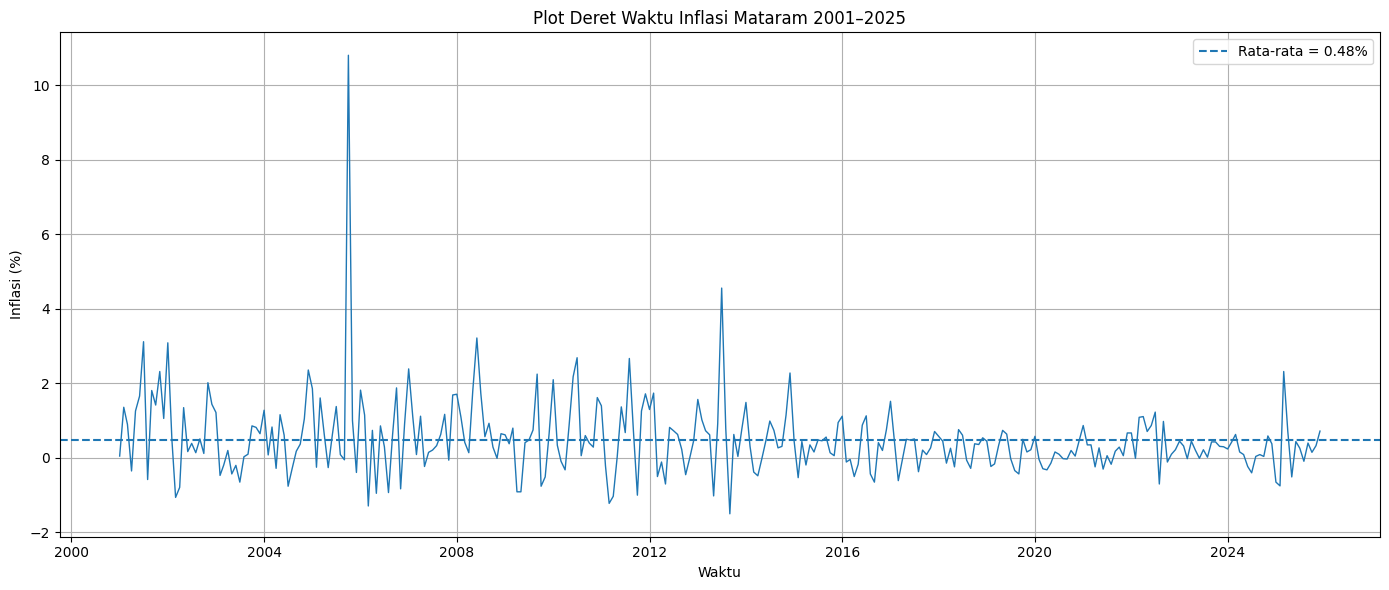

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    ts.index,
    ts.values,
    linewidth=1
)

plt.axhline(
    ts.mean(),
    linestyle="--",
    label=f"Rata-rata = {ts.mean():.2f}%"
)

plt.title("Plot Deret Waktu Inflasi Mataram 2001–2025")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()

plt.tight_layout()
plt.show()

melihat lonjakan

In [14]:
ts.idxmax(), ts.max()

(Timestamp('2005-10-01 00:00:00'), 10.8)

terendah

In [16]:
ts.idxmin(), ts.min()

(Timestamp('2013-09-01 00:00:00'), -1.51)

Statistik Dasar

In [18]:
print("Mean     :", ts.mean())
print("Median   :", ts.median())
print("Variance :", ts.var())
print("Std Dev  :", ts.std())
print("Minimum  :", ts.min())
print("Maximum  :", ts.max())

Mean     : 0.4772
Median   : 0.355
Variance : 1.031182769230769
Std Dev  : 1.0154716978974692
Minimum  : -1.51
Maximum  : 10.8


Melihat nilai tengah sepanjang waktu

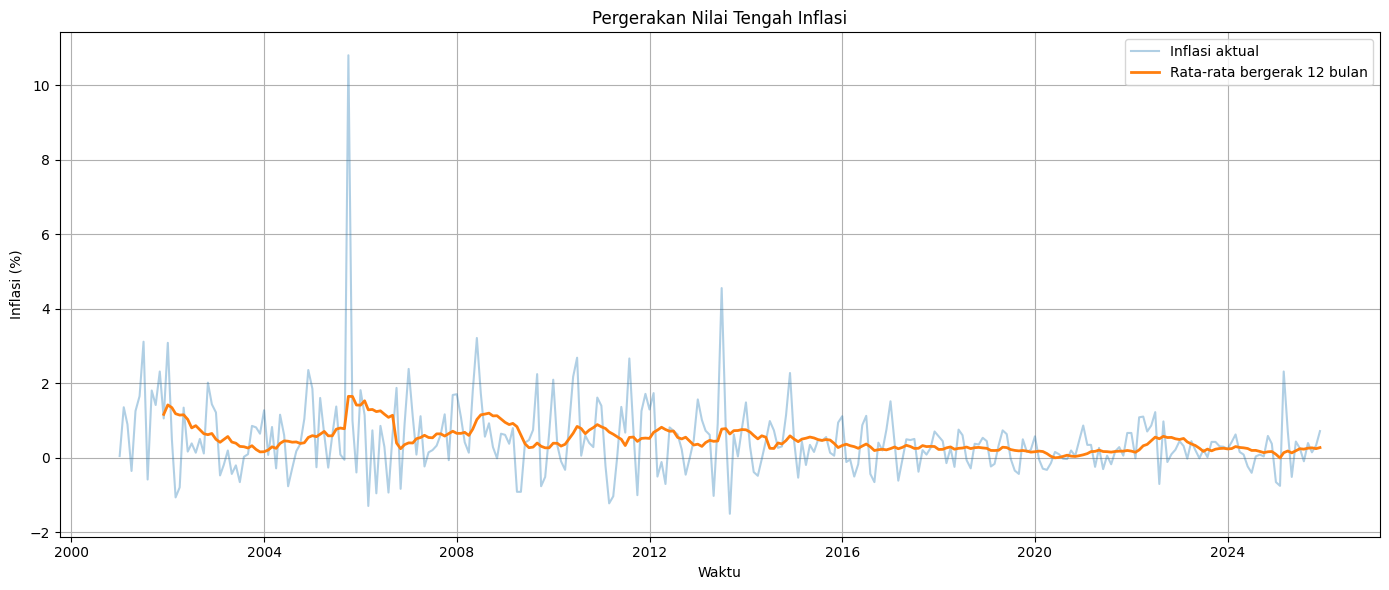

In [19]:
rolling_mean = ts.rolling(window=12).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    ts,
    alpha=0.35,
    label="Inflasi aktual"
)

plt.plot(
    rolling_mean,
    linewidth=2,
    label="Rata-rata bergerak 12 bulan"
)

plt.title("Pergerakan Nilai Tengah Inflasi")
plt.xlabel("Waktu")
plt.ylabel("Inflasi (%)")
plt.legend()

plt.tight_layout()
plt.show()

Melihat nilai ragam sepanjang waktu

menggunakan rolling standar deviation

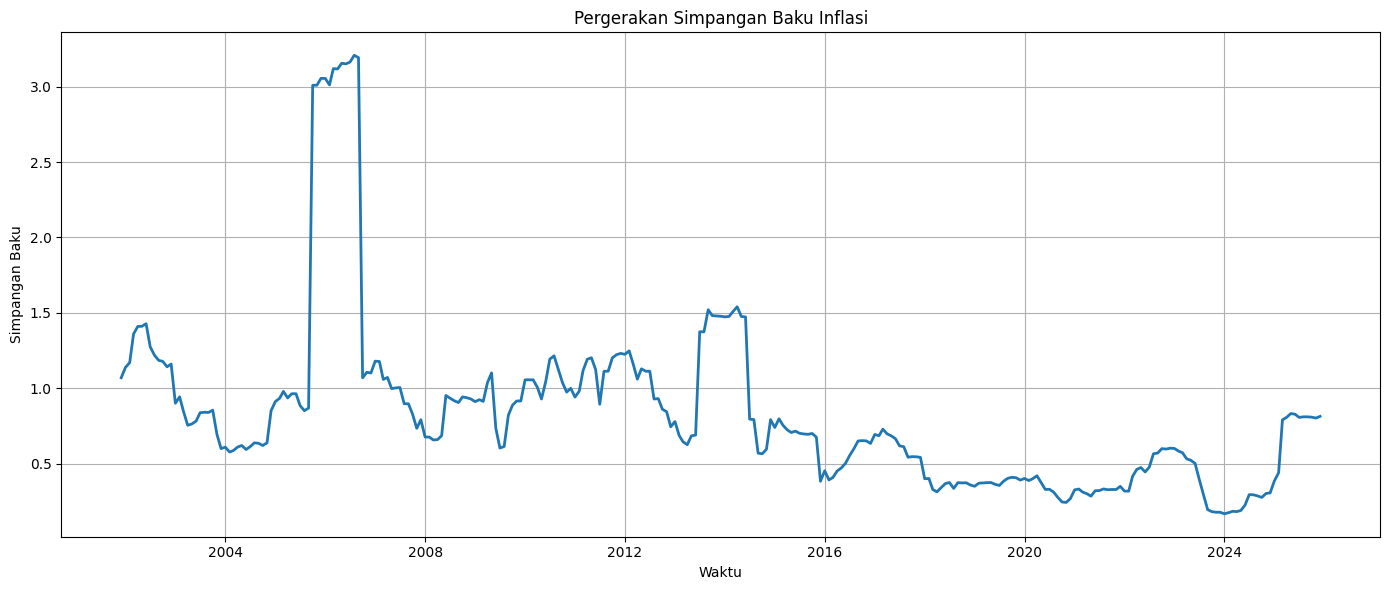

In [21]:
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(14, 6))

plt.plot(
    rolling_std,
    linewidth=2
)

plt.title("Pergerakan Simpangan Baku Inflasi")
plt.xlabel("Waktu")
plt.ylabel("Simpangan Baku")

plt.tight_layout()
plt.show()

Membandingkan mean dan ragam antarperiode

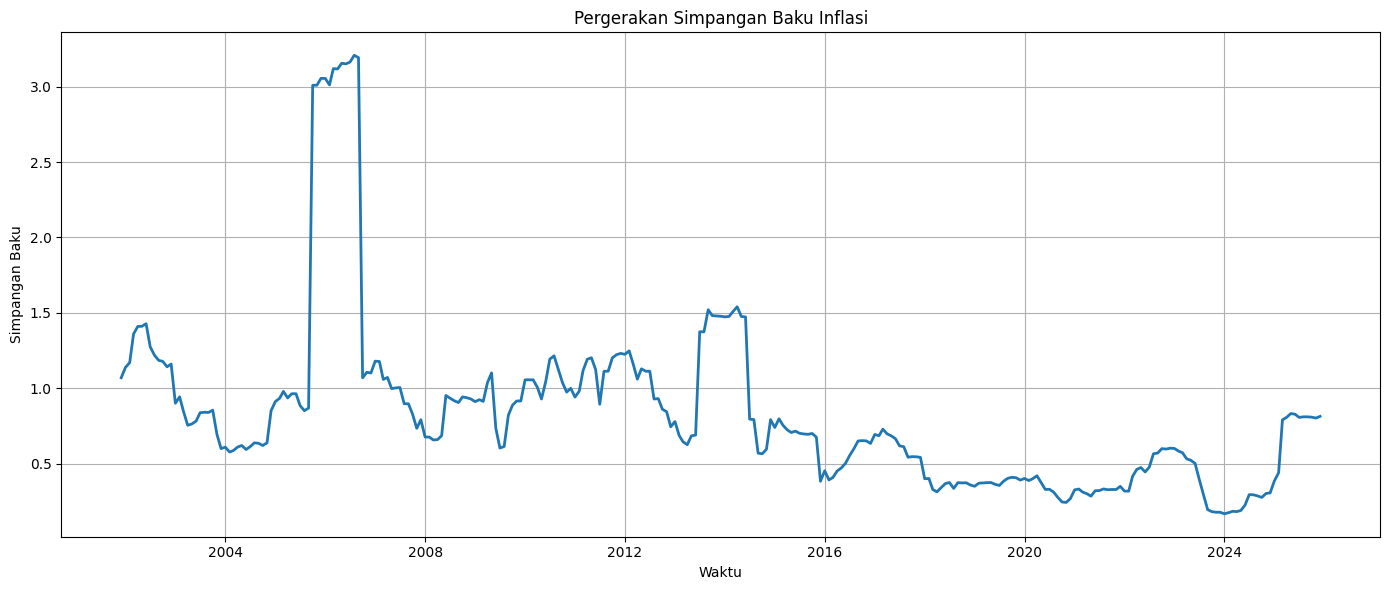

In [22]:
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(14, 6))

plt.plot(
    rolling_std,
    linewidth=2
)

plt.title("Pergerakan Simpangan Baku Inflasi")
plt.xlabel("Waktu")
plt.ylabel("Simpangan Baku")

plt.tight_layout()
plt.show()

Scatterplot

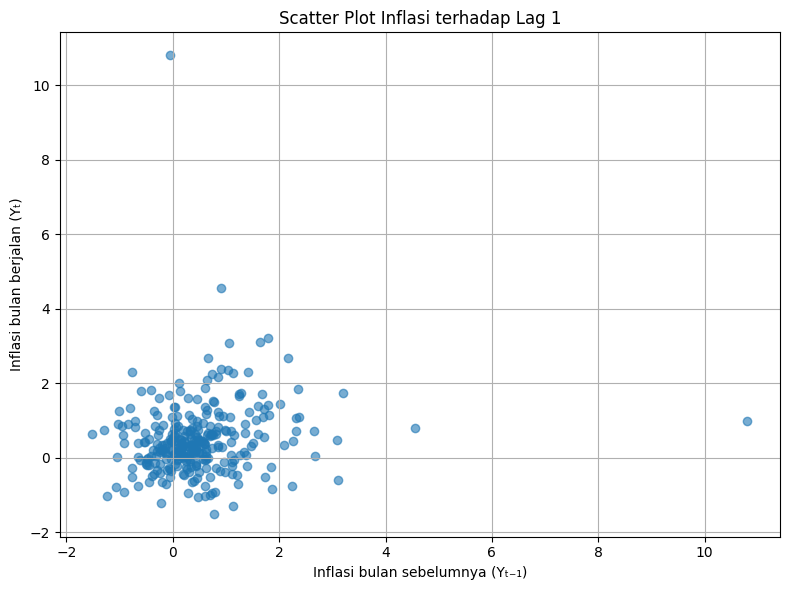

In [23]:
lag1 = pd.DataFrame({
    "Inflasi_t": ts,
    "Inflasi_t-1": ts.shift(1)
}).dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    lag1["Inflasi_t-1"],
    lag1["Inflasi_t"],
    alpha=0.6
)

plt.xlabel("Inflasi bulan sebelumnya (Yₜ₋₁)")
plt.ylabel("Inflasi bulan berjalan (Yₜ)")
plt.title("Scatter Plot Inflasi terhadap Lag 1")

plt.tight_layout()
plt.show()

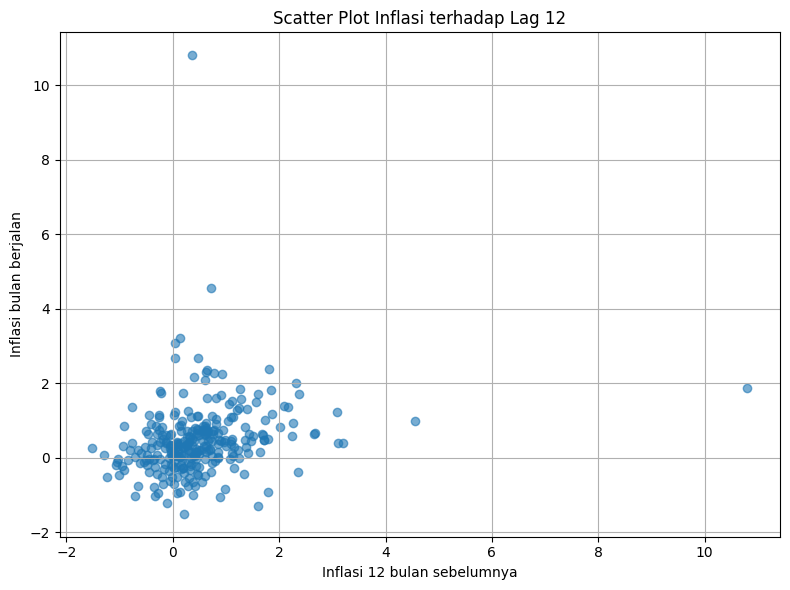

In [24]:
lag12 = pd.DataFrame({
    "Inflasi_t": ts,
    "Inflasi_t-12": ts.shift(12)
}).dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    lag12["Inflasi_t-12"],
    lag12["Inflasi_t"],
    alpha=0.6
)

plt.xlabel("Inflasi 12 bulan sebelumnya")
plt.ylabel("Inflasi bulan berjalan")
plt.title("Scatter Plot Inflasi terhadap Lag 12")

plt.tight_layout()
plt.show()

Boxplot

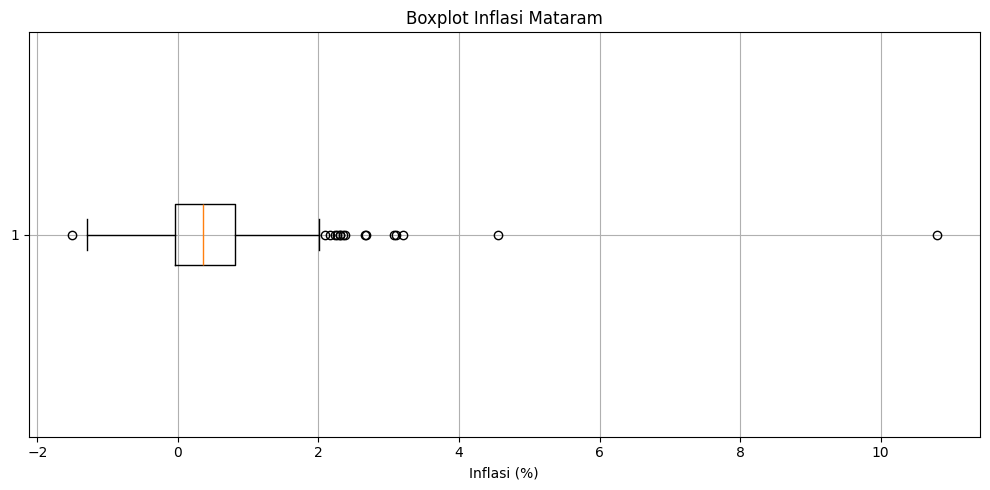

In [25]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    ts,
    vert=False
)

plt.xlabel("Inflasi (%)")
plt.title("Boxplot Inflasi Mataram")

plt.tight_layout()
plt.show()

Boxplot berdasarkan bulan

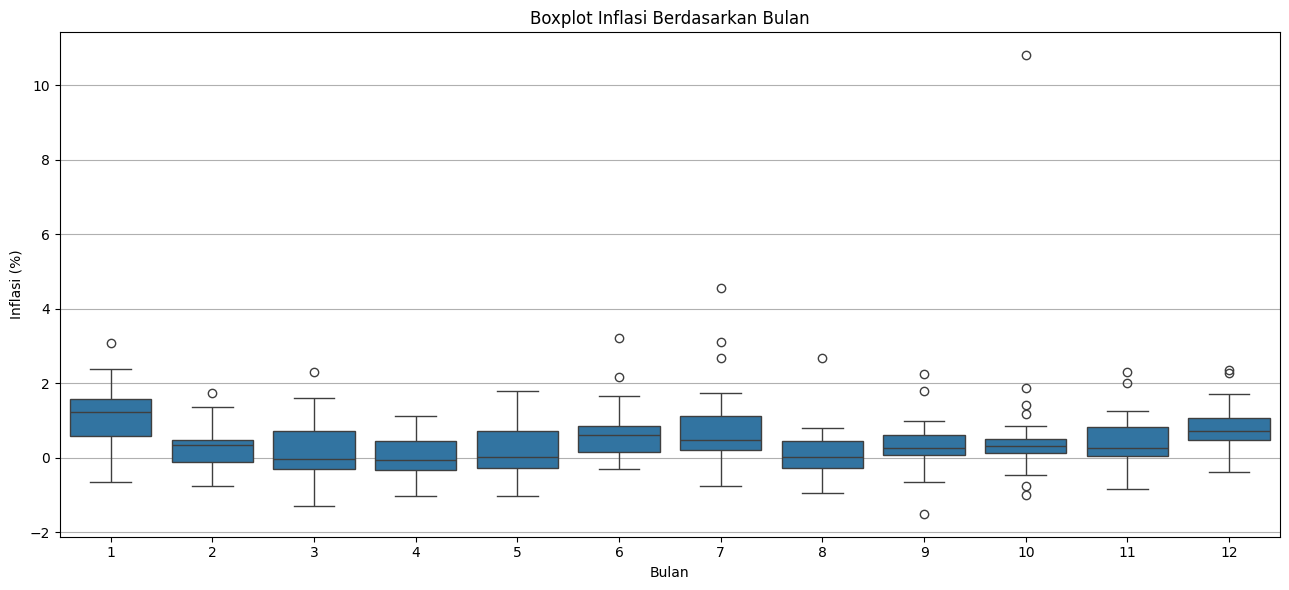

In [26]:
df["bulan"] = df["tahun"].dt.month

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df,
    x="bulan",
    y="inflasi"
)

plt.title("Boxplot Inflasi Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Inflasi (%)")

plt.tight_layout()
plt.show()

ACF

<Figure size 1200x500 with 0 Axes>

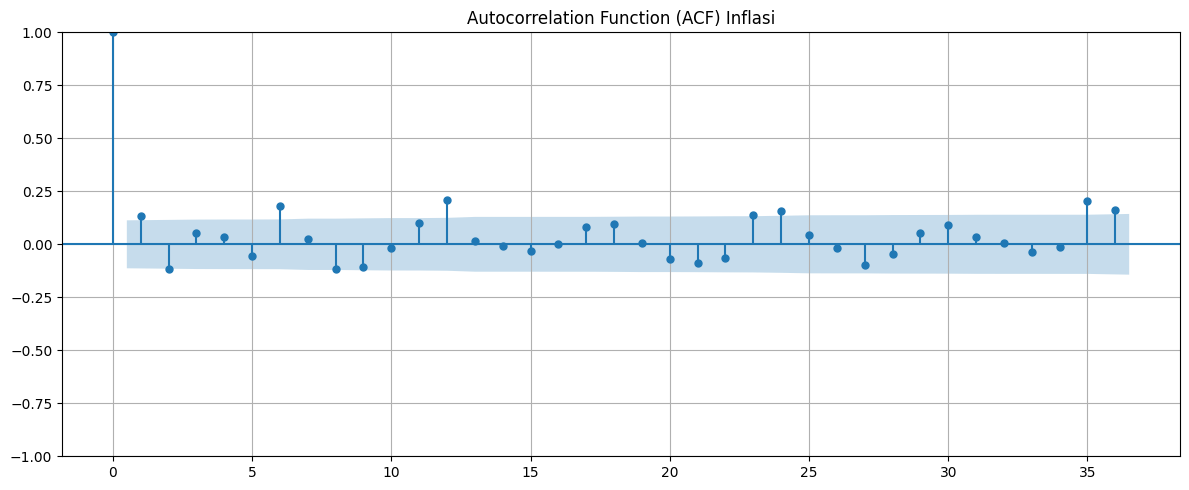

In [27]:
plt.figure(figsize=(12, 5))

plot_acf(
    ts.dropna(),
    lags=36,
    alpha=0.05
)

plt.title("Autocorrelation Function (ACF) Inflasi")

plt.tight_layout()
plt.show()

PACF

<Figure size 1200x500 with 0 Axes>

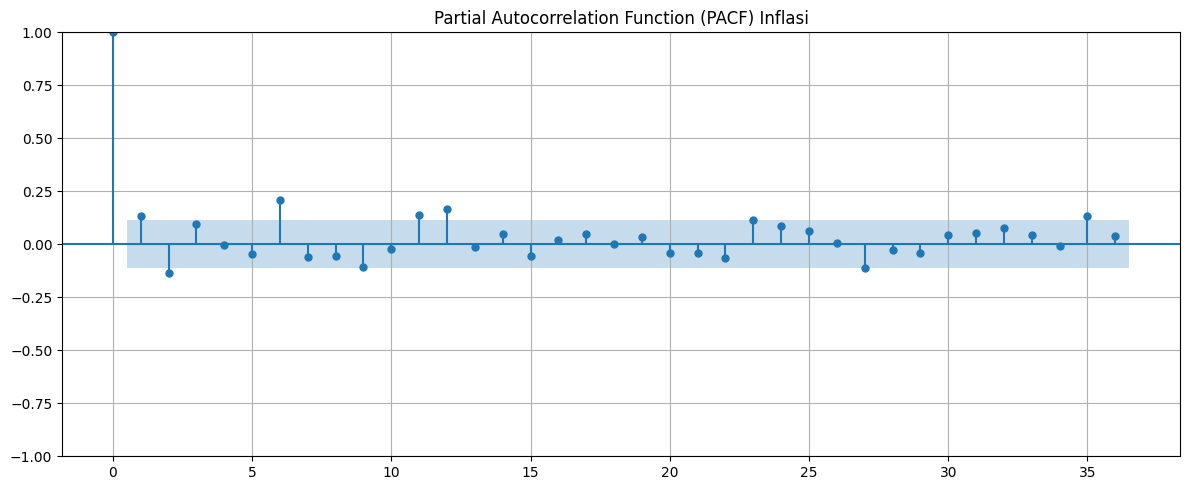

In [ ]:
plt.figure(figsize=(12, 5))

plot_pacf(
    ts.dropna(),
    lags=36,
    alpha=0.05,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF) Inflasi")

plt.tight_layout()
plt.show()

Gabungan ACF dan PACF

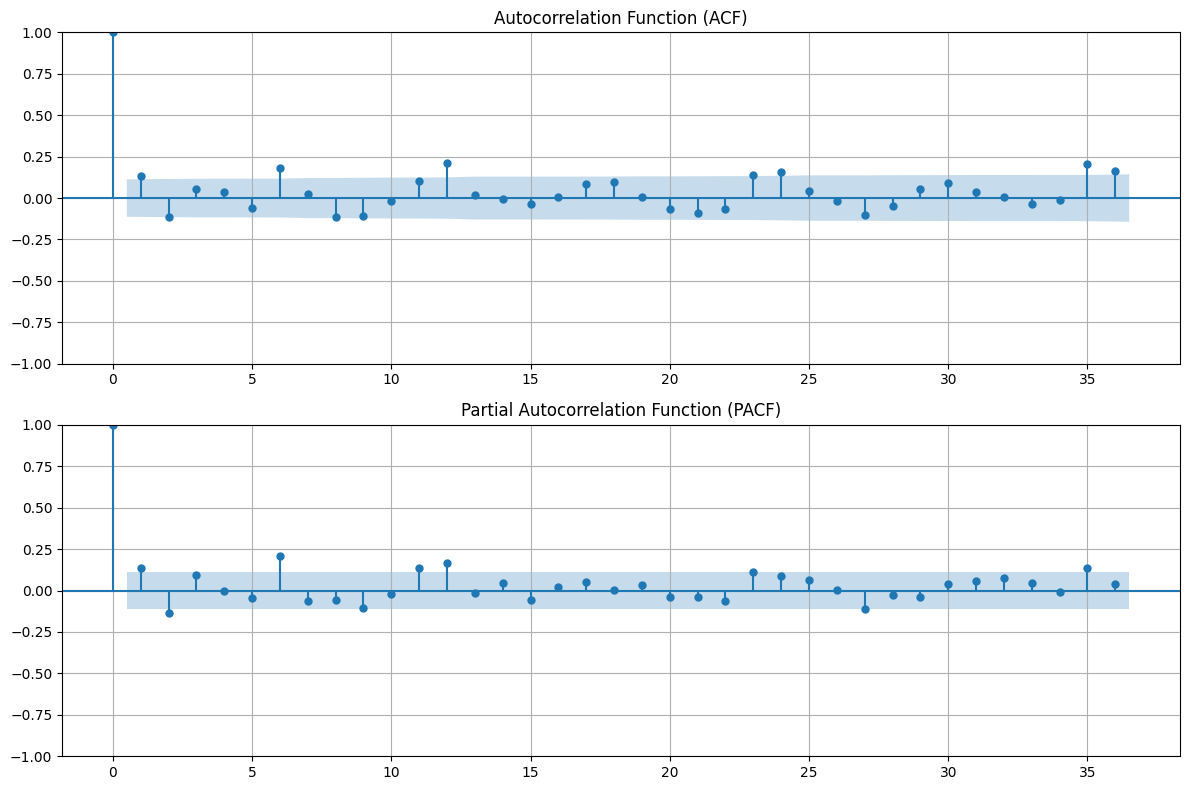

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(
    ts.dropna(),
    lags=36,
    alpha=0.05,
    ax=axes[0]
)

axes[0].set_title("Autocorrelation Function (ACF)")

# PACF
plot_pacf(
    ts.dropna(),
    lags=36,
    alpha=0.05,
    method="ywm",
    ax=axes[1]
)

axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

Uji Stasioneritas ADF

In [29]:
adf_result = adfuller(
    ts.dropna(),
    autolag="AIC"
)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Lag digunakan :", adf_result[2])
print("Observasi     :", adf_result[3])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.208734307580341
p-value       : 0.0006368243610441704
Lag digunakan : 11
Observasi     : 288

Critical Values:
1%: -3.453261605529366
5%: -2.87162848654246
10%: -2.5721455328896603


Melihat total data

In [30]:
print(len(ts))

300


Identifikasi Pola Musiman

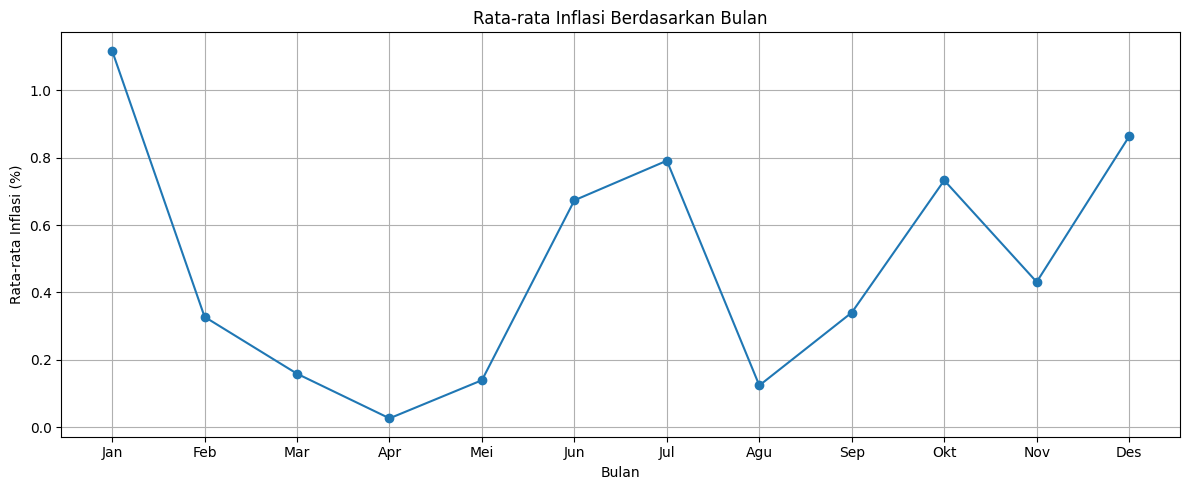

In [31]:
df["bulan"] = df["tahun"].dt.month

rata_bulan = df.groupby("bulan")["inflasi"].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    rata_bulan.index,
    rata_bulan.values,
    marker="o"
)

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
     "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]
)

plt.xlabel("Bulan")
plt.ylabel("Rata-rata Inflasi (%)")
plt.title("Rata-rata Inflasi Berdasarkan Bulan")

plt.tight_layout()
plt.show()

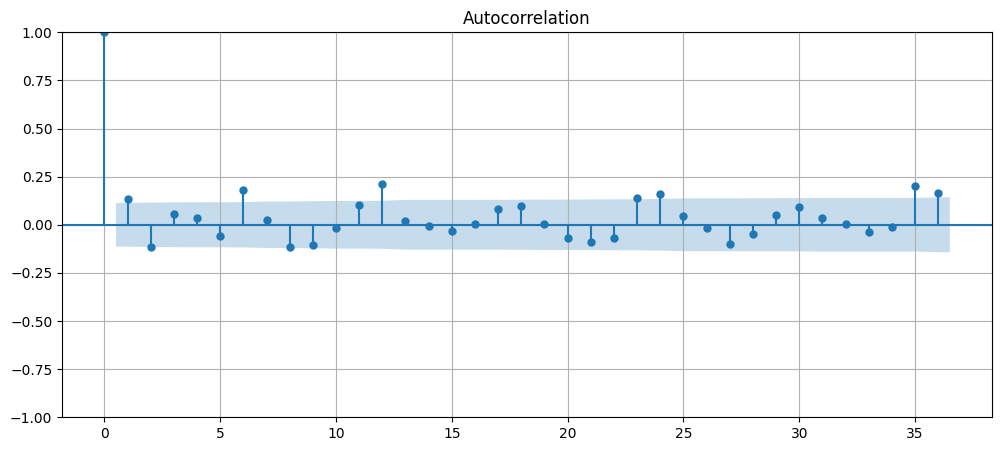

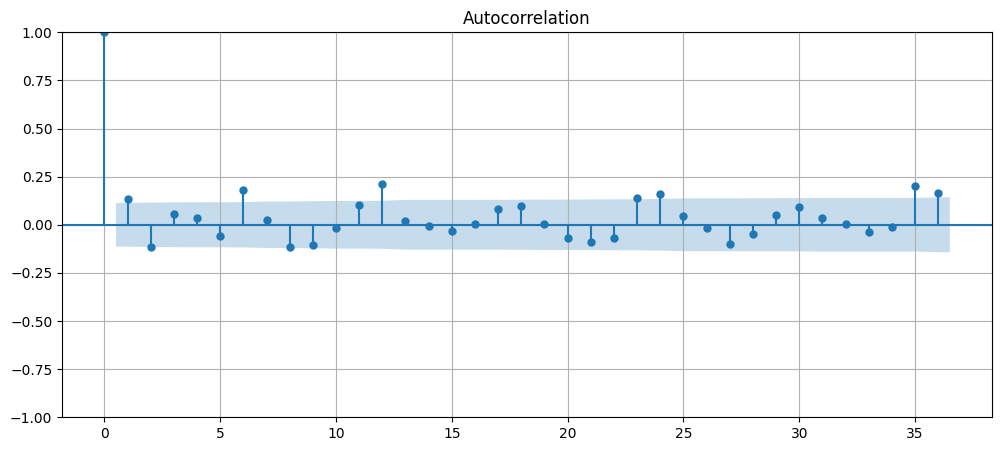

In [32]:
plot_acf(ts.dropna(), lags=36)

Dekomposisi Deret Waktu

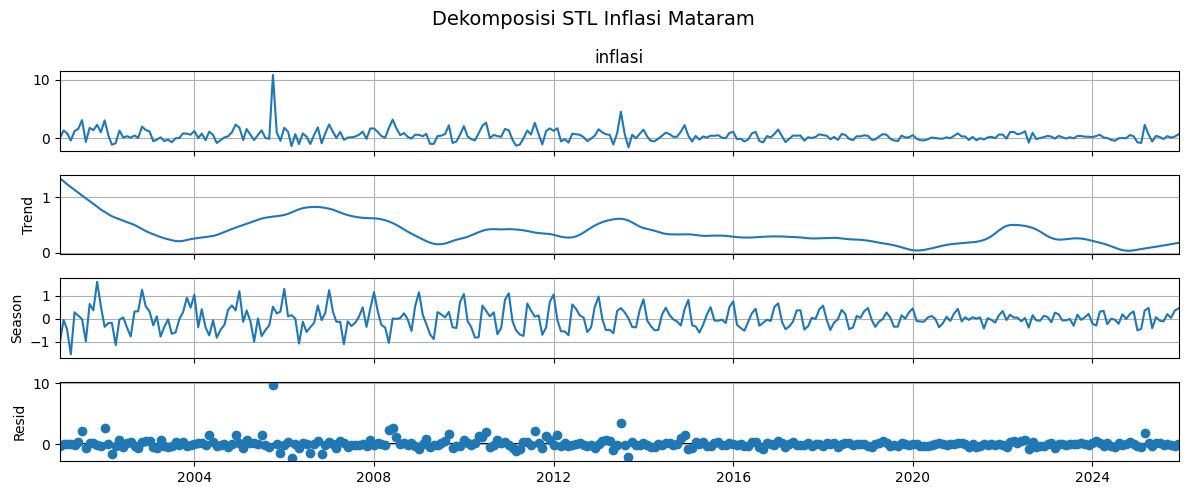

In [33]:
from statsmodels.tsa.seasonal import STL

stl = STL(
    ts,
    period=12,
    robust=True
)

hasil_stl = stl.fit()

hasil_stl.plot()

plt.suptitle(
    "Dekomposisi STL Inflasi Mataram",
    fontsize=14
)

plt.tight_layout()
plt.show()

Cek Outlier

1. Tertinggi



In [34]:
print(
    ts.nlargest(10)
)

tahun
2005-10-01    10.80
2013-07-01     4.55
2008-06-01     3.21
2001-07-01     3.11
2002-01-01     3.08
2010-07-01     2.68
2011-08-01     2.66
2007-01-01     2.38
2004-12-01     2.35
2001-11-01     2.31
Name: inflasi, dtype: float64


2. Terendah

In [35]:
print(
    ts.nsmallest(10)
)

tahun
2013-09-01   -1.51
2006-03-01   -1.30
2011-03-01   -1.23
2002-03-01   -1.07
2011-04-01   -1.04
2013-05-01   -1.03
2011-10-01   -1.01
2006-05-01   -0.96
2006-08-01   -0.94
2009-04-01   -0.92
Name: inflasi, dtype: float64


Membuat Box-cox

In [36]:
ts = df.set_index("tahun")["inflasi"]

In [37]:
print("Nilai minimum:", ts.min())

Nilai minimum: -1.51




*   Buat data menjadi positif


In [39]:
# Konstanta untuk menggeser data
c = abs(ts.min()) + 0.01

# Data setelah digeser
ts_shift = ts + c

print("Konstanta shift:", c)
print("Minimum setelah shift:", ts_shift.min())

Konstanta shift: 1.52
Minimum setelah shift: 0.010000000000000009




*   Lakukan Box-cox



In [40]:
from scipy.stats import boxcox

# Transformasi Box-Cox
ts_boxcox, lambda_boxcox = boxcox(ts_shift)

print("Lambda Box-Cox:", lambda_boxcox)

Lambda Box-Cox: 0.40341275241742397




*   Jadikan kembali menjadi series



In [41]:
ts_boxcox = pd.Series(
    ts_boxcox,
    index=ts.index,
    name="inflasi_boxcox"
)

ts_boxcox.head()

,inflasi_boxcox
tahun,
2001-01-01,0.487068
2001-02-01,1.314000
2001-03-01,1.055917
2001-04-01,0.152953
2001-05-01,1.260123


- Perbandingan grafik sebelum dan sesudah transformasi

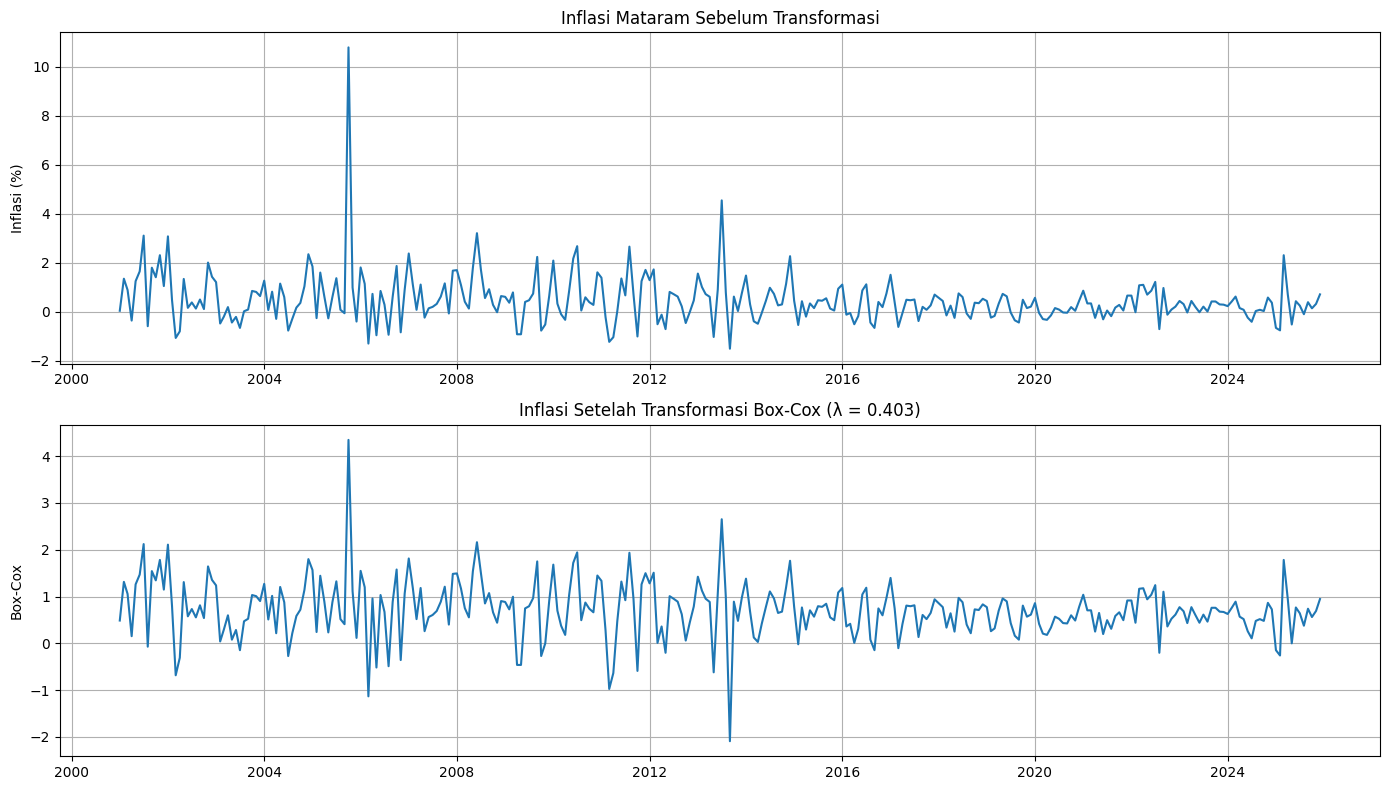

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Data asli
axes[0].plot(ts)
axes[0].set_title("Inflasi Mataram Sebelum Transformasi")
axes[0].set_ylabel("Inflasi (%)")

# Data Box-Cox
axes[1].plot(ts_boxcox)
axes[1].set_title(
    f"Inflasi Setelah Transformasi Box-Cox (λ = {lambda_boxcox:.3f})"
)
axes[1].set_ylabel("Box-Cox")

plt.tight_layout()
plt.show()

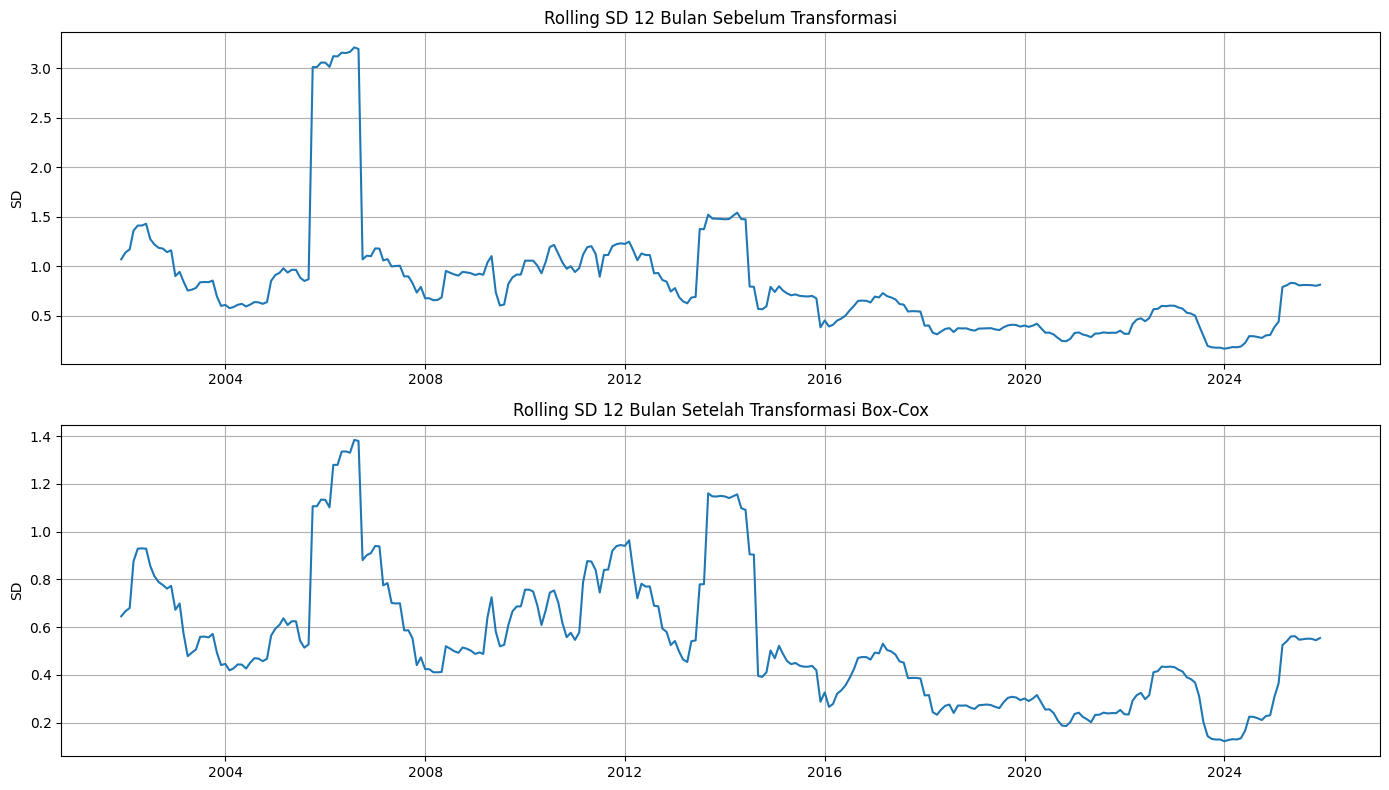

In [54]:
rolling_sd_asli = ts.rolling(12).std()
rolling_sd_boxcox = ts_boxcox.rolling(12).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8)
)

# Sebelum transformasi
axes[0].plot(rolling_sd_asli)
axes[0].set_title(
    "Rolling SD 12 Bulan Sebelum Transformasi"
)
axes[0].set_ylabel("SD")

# Sesudah transformasi
axes[1].plot(rolling_sd_boxcox)
axes[1].set_title(
    "Rolling SD 12 Bulan Setelah Transformasi Box-Cox"
)
axes[1].set_ylabel("SD")

plt.tight_layout()
plt.show()

- membandingkan ragam sebelum dan sesudah transformasi

In [45]:
print("Ragam sebelum Box-Cox :", ts.var())
print("Ragam setelah Box-Cox :", ts_boxcox.var())

print("\nSD sebelum Box-Cox :", ts.std())
print("SD setelah Box-Cox :", ts_boxcox.std())

Ragam sebelum Box-Cox : 1.031182769230769
Ragam setelah Box-Cox : 0.3653143211505495

SD sebelum Box-Cox : 1.0154716978974692
SD setelah Box-Cox : 0.6044123767350811


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, boxcox_normmax

# Karena data inflasi memiliki nilai negatif
shift = abs(ts.min()) + 0.01
ts_positive = ts + shift

lambda_opt = boxcox_normmax(
    ts_positive,
    method="mle"
)

print("Lambda optimal:", lambda_opt)

Lambda optimal: 0.40341275241742397


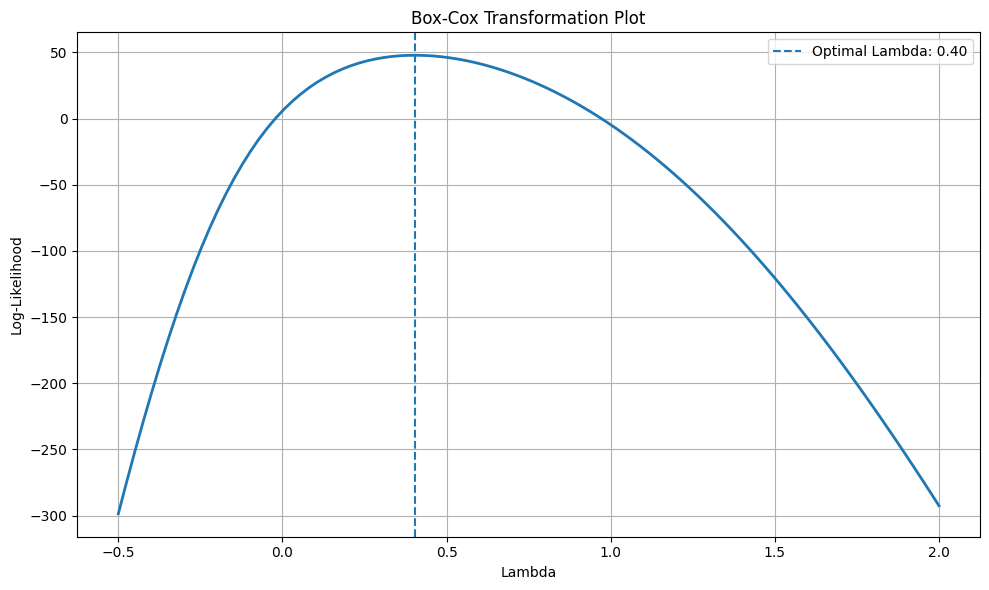

In [47]:
# ============================================================
# 3. BOX-COX TRANSFORMATION PLOT
# ============================================================

lambdas = np.linspace(-0.5, 2, 100)

loglikelihood = []

for lam in lambdas:

    if abs(lam) < 1e-8:
        transformed = np.log(ts_positive)
    else:
        transformed = (
            ts_positive ** lam - 1
        ) / lam

    # log-likelihood
    n = len(transformed)

    variance = np.var(
        transformed,
        ddof=1
    )

    ll = (
        -(n / 2) * np.log(variance)
        + (lam - 1) * np.sum(np.log(ts_positive))
    )

    loglikelihood.append(ll)

loglikelihood = np.array(loglikelihood)

# ============================================================
# 4. PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    lambdas,
    loglikelihood,
    linewidth=2
)

# Lambda optimal
plt.axvline(
    lambda_opt,
    linestyle="--",
    label=f"Optimal Lambda: {lambda_opt:.2f}"
)

plt.xlabel("Lambda")
plt.ylabel("Log-Likelihood")
plt.title("Box-Cox Transformation Plot")

plt.legend()

plt.tight_layout()
plt.show()

In [48]:
from scipy.stats import boxcox

transformed, lambda_opt, ci = boxcox(
    ts_positive,
    alpha=0.05
)

print("Lambda optimal :", lambda_opt)
print("95% CI         :", ci)

Lambda optimal : 0.40341275241742397
95% CI         : (0.3036175174434397, 0.5096877698307049)


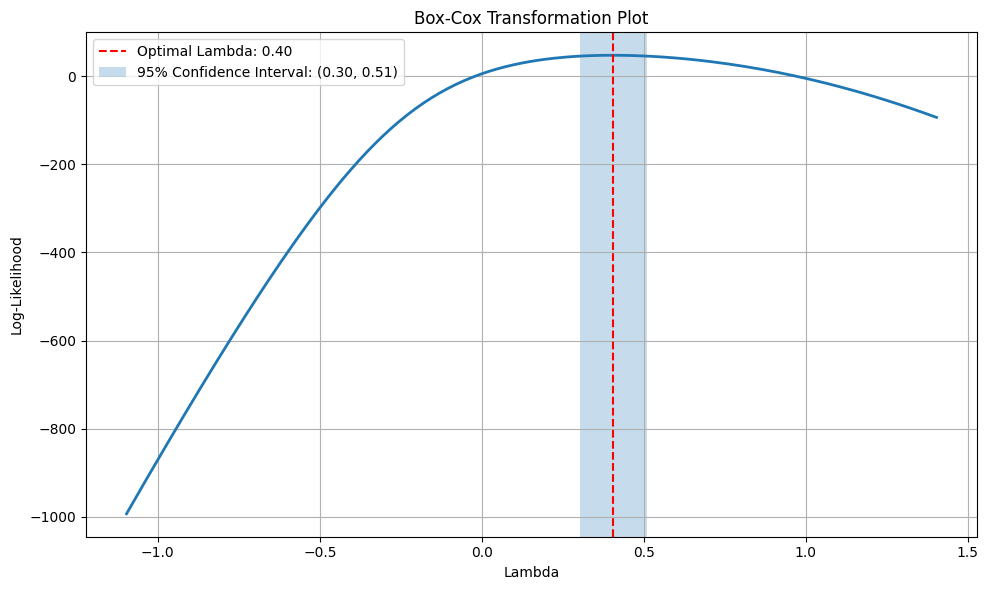

In [49]:
# ============================================================
# MEMBUAT BOX-COX TRANSFORMATION PLOT
# ============================================================

lambdas = np.linspace(
    lambda_opt - 1.5,
    lambda_opt + 1.0,
    200
)

loglikelihood = []

n = len(ts_positive)

for lam in lambdas:

    if abs(lam) < 1e-8:
        y_trans = np.log(ts_positive)
    else:
        y_trans = (
            ts_positive ** lam - 1
        ) / lam

    variance = np.var(
        y_trans,
        ddof=1
    )

    ll = (
        -(n / 2) * np.log(variance)
        + (lam - 1) * np.sum(
            np.log(ts_positive)
        )
    )

    loglikelihood.append(ll)

loglikelihood = np.array(loglikelihood)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    lambdas,
    loglikelihood,
    linewidth=2
)

# Lambda optimal
plt.axvline(
    lambda_opt,
    color="red",
    linestyle="--",
    label=f"Optimal Lambda: {lambda_opt:.2f}"
)

# Confidence interval
plt.axvspan(
    ci[0],
    ci[1],
    alpha=0.25,
    label=f"95% Confidence Interval: "
          f"({ci[0]:.2f}, {ci[1]:.2f})"
)

plt.xlabel("Lambda")
plt.ylabel("Log-Likelihood")
plt.title("Box-Cox Transformation Plot")

plt.legend()

plt.tight_layout()
plt.show()